In [23]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [24]:
# Load the training dataset
train_data = pd.read_csv('FiReCS_train_set.csv')

# Separate the features and target variables
X_train = train_data['review']
y_train = train_data['label']

In [25]:
# Create feature extractors
bow_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [27]:
# Logistic Regression
lr_params = {'C': [0.1, 1, 10]}
lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5)
lr_grid.fit(X_train_tfidf, y_train)
lr_best = lr_grid.best_estimator_

In [28]:
# SVM
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5)
svm_grid.fit(X_train_tfidf, y_train)
svm_best = svm_grid.best_estimator_

In [29]:
# Random Forest
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2, 4]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train_tfidf, y_train)
rf_best = rf_grid.best_estimator_

In [30]:
test_data = pd.read_csv('FiReCS_test_set.csv')

# Extract features from the test data
X_test_tfidf = tfidf_vectorizer.transform(test_data['review'])

In [31]:
## 4. Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate Logistic Regression
lr_pred = lr_best.predict(X_test_tfidf)
print("Logistic Regression:")
print("Accuracy:", accuracy_score(test_data['label'], lr_pred))
print("Precision (weighted):", precision_score(test_data['label'], lr_pred, average='weighted'))
print("Recall (weighted):", recall_score(test_data['label'], lr_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(test_data['label'], lr_pred, average='weighted'))

# Evaluate SVM
svm_pred = svm_best.predict(X_test_tfidf)
print("\nSVM:")
print("Accuracy:", accuracy_score(test_data['label'], svm_pred))
print("Precision (weighted):", precision_score(test_data['label'], svm_pred, average='weighted'))
print("Recall (weighted):", recall_score(test_data['label'], svm_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(test_data['label'], svm_pred, average='weighted'))

# Evaluate Random Forest
rf_pred = rf_best.predict(X_test_tfidf)
print("\nRandom Forest:")
print("Accuracy:", accuracy_score(test_data['label'], rf_pred))
print("Precision (weighted):", precision_score(test_data['label'], rf_pred, average='weighted'))
print("Recall (weighted):", recall_score(test_data['label'], rf_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(test_data['label'], rf_pred, average='weighted'))

## 5. Model Selection

# Select the best-performing model based on test performance
best_model = max(
    lr_best, svm_best, rf_best,
    key=lambda model: f1_score(test_data['label'], model.predict(X_test_tfidf), average='weighted')
)

print("\nBest Model:")
if best_model == lr_best:
    print("Logistic Regression")
elif best_model == svm_best:
    print("SVM")
else:
    print("Random Forest")


Logistic Regression:
Accuracy: 0.7942206654991243
Precision (weighted): 0.7978955058101054
Recall (weighted): 0.7942206654991243
F1 Score (weighted): 0.7954963056618907

SVM:
Accuracy: 0.7985989492119089
Precision (weighted): 0.8055494914863499
Recall (weighted): 0.7985989492119089
F1 Score (weighted): 0.8005892824443281

Random Forest:
Accuracy: 0.7697022767075307
Precision (weighted): 0.7732423847422024
Recall (weighted): 0.7697022767075307
F1 Score (weighted): 0.7708185676695765

Best Model:
SVM


In [47]:
from sklearn.metrics import confusion_matrix

# Logistic Regression
lr_cm = confusion_matrix(test_data['label'], lr_pred)
print("Logistic Regression Confusion Matrix:")
print(lr_cm)

# SVM
svm_cm = confusion_matrix(test_data['label'], svm_pred)
print("\nSVM Confusion Matrix:")
print(svm_cm)

# Random Forest
rf_cm = confusion_matrix(test_data['label'], rf_pred)
print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

Logistic Regression Confusion Matrix:
[[891 207  18]
 [197 917  94]
 [ 37 152 913]]

SVM Confusion Matrix:
[[898 208  10]
 [196 941  71]
 [ 38 167 897]]

Random Forest Confusion Matrix:
[[841 233  42]
 [181 902 125]
 [ 37 171 894]]


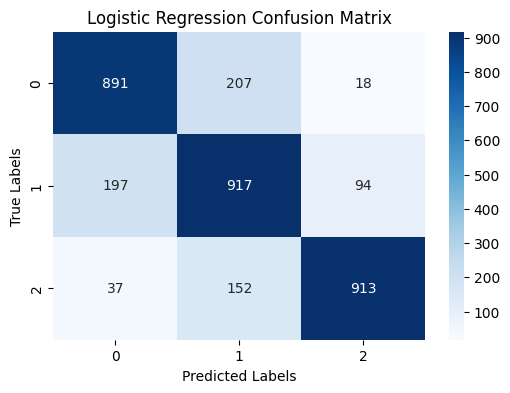

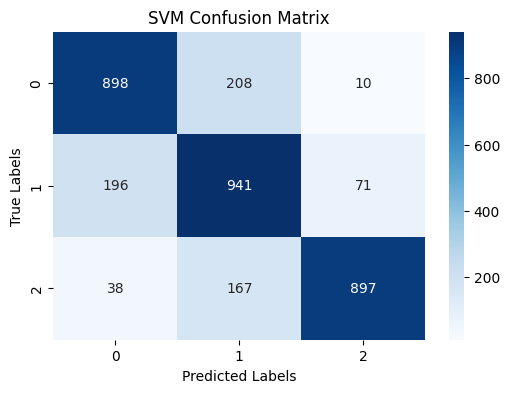

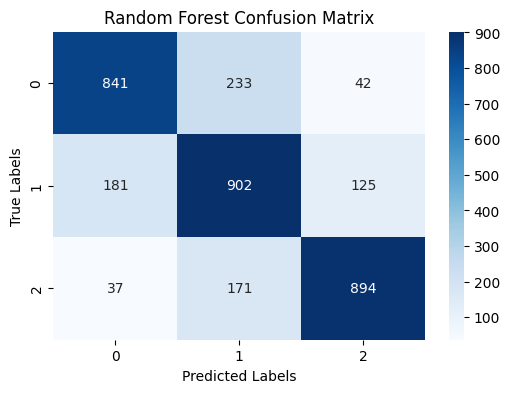

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm, annot=True, cmap='Blues', fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# SVM
plt.figure(figsize=(6, 4))
sns.heatmap(svm_cm, annot=True, cmap='Blues', fmt='d')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, cmap='Blues', fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [32]:
# Save the best model
import joblib
joblib.dump(best_model, 'best_sentiment_model_EVER.pkl')

['best_sentiment_model_EVER.pkl']

Model Testing

In [45]:
# Load the saved model
import joblib
loaded_model = joblib.load('best_sentiment_model_EVER.pkl')

# Get user input
input_text = input("Enter a text to predict its sentiment: ")

# Transform the preprocessed input using the trained vectorizer
input_features = tfidf_vectorizer.transform([input_text])

# Make the prediction
predicted_sentiment = loaded_model.predict(input_features)[0]

# Map the predicted sentiment to a label (if applicable)
sentiment_labels = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}  # Adjust labels based on your data
predicted_label = sentiment_labels[predicted_sentiment]

print("Predicted Sentiment:", predicted_label)

Predicted Sentiment: NEUTRAL
